# 01 — pKa_Acidic: official benchmark-paper configuration (GraphMPNN)

Reproduces this project's **current best** result for pKa_Acidic against the published
benchmark, using the exact protocol of `mfmn_v3/experiments/e13_final_confirmation.py`:
fit on the **official train split only**, predict on the **official held-out test split
only**, **10-seed ensemble** (mean of 10 independently-trained models), from-scratch GNN
(no pretraining -- the E13 CV ablation found pretraining contributes nothing measurable at
this data scale). This is the confirmatory, one-shot-on-the-real-test-set protocol this
project reserves for after architecture selection is finished, not an internal CV estimate.

Architecture: `GraphMPNN` (4-layer edge-gated message-passing GNN, hidden_dim=128,
dropout=0.1, 587,905 params) -- the same, unmodified production baseline used throughout
this project. Reference numbers this run is directly compared against are the published
benchmark paper's own values (`PAPER` in `metrics.py`).


In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from graph_mpnn import GraphMPNN, count_params
from graph_features import mol_to_graph, batch_graphs, NODE_FEATURE_DIM, EDGE_FEATURE_DIM
from acidic_site import find_acidic_site
import data_loader
from metrics import eval_preds, PAPER

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
TARGET = "pKa_Acidic"


device: cuda


In [2]:
# ---- config: matches e13/e14_final_confirmation.py exactly ----
HIDDEN_DIM, N_LAYERS, DROPOUT = 128, 4, 0.1
EPOCHS, LR, BATCH, PATIENCE, VAL_FRAC = 300, 5e-4, 64, 40, 0.15
N_SEEDS = 10  # matches the established v2/v3 final-confirmation convention
print(f"target={TARGET} n_seeds={N_SEEDS} epochs={EPOCHS}")


target=pKa_Acidic n_seeds=10 epochs=300


In [3]:
def to_device_batch(graph_list):
    nodes, adj, adj_mask, node_mask, site_idx = batch_graphs(graph_list)
    t = lambda a, dt=torch.float32: torch.tensor(a, dtype=dt, device=DEVICE)
    return t(nodes), t(adj), t(adj_mask), t(node_mask), t(site_idx, torch.int64)


def predict_chunked(model, graphs, batch=BATCH):
    # Chunked so an entire (~800-compound) official test set is never materialized as one
    # dense [B,N,N,H] tensor -- numerically identical to a single unbatched call since
    # model.eval() disables dropout and there is no batchnorm.
    preds = []
    with torch.no_grad():
        for st in range(0, len(graphs), batch):
            nodes, adj, adj_mask, node_mask, site_idx = to_device_batch(graphs[st:st + batch])
            preds.append(model.forward_finetune(nodes, adj, adj_mask, node_mask, site_idx).cpu().numpy())
    return np.concatenate(preds)


def fit_predict_gnn(graphs, y_all, train_pos, test_pos, seed, verbose=False):
    y_mu, y_sd = y_all[train_pos].mean(), y_all[train_pos].std()
    y_s = (y_all - y_mu) / y_sd

    torch.manual_seed(seed)
    model = GraphMPNN(NODE_FEATURE_DIM, EDGE_FEATURE_DIM, hidden_dim=HIDDEN_DIM,
                      n_layers=N_LAYERS, dropout=DROPOUT).add_finetune_head(1).to(DEVICE)
    if verbose:
        print(f"    params={count_params(model)}")

    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(train_pos))
    n_val = max(1, int(VAL_FRAC * len(train_pos)))
    val_pos, fit_pos = train_pos[perm[:n_val]], train_pos[perm[n_val:]]

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best, best_state, bad = np.inf, None, 0
    for ep in range(EPOCHS):
        model.train()
        ep_perm = rng.permutation(len(fit_pos))
        for st in range(0, len(fit_pos), BATCH):
            idx = fit_pos[ep_perm[st:st + BATCH]]
            nodes, adj, adj_mask, node_mask, site_idx = to_device_batch([graphs[i] for i in idx])
            pred = model.forward_finetune(nodes, adj, adj_mask, node_mask, site_idx)
            target_t = torch.tensor(y_s[idx], dtype=torch.float32, device=DEVICE)
            loss = nn.functional.smooth_l1_loss(pred, target_t, beta=0.5)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()
        sched.step()
        model.eval()
        vpred = predict_chunked(model, [graphs[i] for i in val_pos])
        vl = np.abs(vpred - y_s[val_pos]).mean()
        if vl < best - 1e-4:
            best, bad, best_state = vl, 0, {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    pred_s = predict_chunked(model, [graphs[i] for i in test_pos])
    return pred_s * y_sd + y_mu


In [4]:
graph_ok, val_col, split_col = data_loader.load_pka_official_split(TARGET)

graphs, keep_rows = [], []
for i, row in graph_ok.iterrows():
    g = mol_to_graph(row["canon_smiles"], row, site_finder=find_acidic_site)
    if g is not None:
        graphs.append(g)
        keep_rows.append(i)
graph_ok = graph_ok.iloc[keep_rows].reset_index(drop=True)
y_all = graph_ok[val_col].values.astype(np.float64)

train_pos = np.where(graph_ok[split_col].values == "train")[0]
test_pos = np.where(graph_ok[split_col].values == "test")[0]
print(f"Official split (after xTB extraction success filter): train={len(train_pos)}  test={len(test_pos)}")


[10:57:11] WARNING: not removing hydrogen atom without neighbors


Official split (after xTB extraction success filter): train=5296  test=776


In [5]:
is_log10 = False  # pKa is evaluated directly in pKa units, not log10 (values can be negative)

preds = []
t0 = time.time()
for s in range(N_SEEDS):
    seed = 42 + s
    p = fit_predict_gnn(graphs, y_all, train_pos, test_pos, seed=seed, verbose=(s == 0))
    preds.append(p)
    m_seed = eval_preds(y_all[test_pos], p, is_log10)
    print(f"[seed {s}] MAE={m_seed['MAE']:.4f} within2={m_seed.get('within_2_pKa_unit'):.4f} "
          f"({time.time()-t0:.0f}s elapsed)", flush=True)

pred = np.mean(np.vstack(preds), axis=0)
m = eval_preds(y_all[test_pos], pred, is_log10)
paper = PAPER[TARGET]
print(f"\n{'='*70}\nFINAL ({N_SEEDS}-seed ensemble): {m}")
print(f"paper: {paper}\n{'='*70}")


    params=587905


[seed 0] MAE=0.4756 within2=0.9742 (588s elapsed)


[seed 1] MAE=0.5054 within2=0.9613 (885s elapsed)


[seed 2] MAE=0.4546 within2=0.9768 (1467s elapsed)


[seed 3] MAE=0.4828 within2=0.9716 (1987s elapsed)


...

[seed 6] MAE=0.4721 within2=0.9652 (3719s elapsed)


[seed 7] MAE=0.4876 within2=0.9729 (4362s elapsed)


[seed 8] MAE=0.4768 within2=0.9652 (4950s elapsed)


[seed 9] MAE=0.5259 within2=0.9613 (5308s elapsed)



FINAL (10-seed ensemble): {'R2': 0.9688766124272525, 'MAE': 0.4240870885693657, 'RMSE': 0.7571448603514502, 'within_1_pKa_unit': 0.9097938144329897, 'within_2_pKa_unit': 0.9742268041237113}
paper: {'R2': 0.94, 'MAE': 0.61, 'RMSE': 1.05, 'GMFE': 1.1, 'within_2fold': 0.98}


In [6]:
os.makedirs("../outputs", exist_ok=True)
out_df = pd.DataFrame({"canon_smiles": graph_ok.iloc[test_pos]["canon_smiles"].values,
                        "y_true": y_all[test_pos], "y_pred": pred})
out_df.to_csv(f"../outputs/01_{TARGET}_official_test_predictions.csv", index=False)

summary = pd.DataFrame([{"target": TARGET, "n_train": len(train_pos), "n_test": len(test_pos),
                         "n_seeds": N_SEEDS, **m, **{f"paper_{k}": v for k, v in paper.items()}}])
summary.to_csv(f"../outputs/01_{TARGET}_official_test_summary.csv", index=False)
print(summary.T)


                             0
target              pKa_Acidic
n_train                   5296
n_test                     776
n_seeds                     10
R2                    0.968877
MAE                   0.424087
RMSE                  0.757145
within_1_pKa_unit     0.909794
within_2_pKa_unit     0.974227
paper_R2                  0.94
paper_MAE                 0.61
paper_RMSE                1.05
paper_GMFE                 1.1
paper_within_2fold        0.98


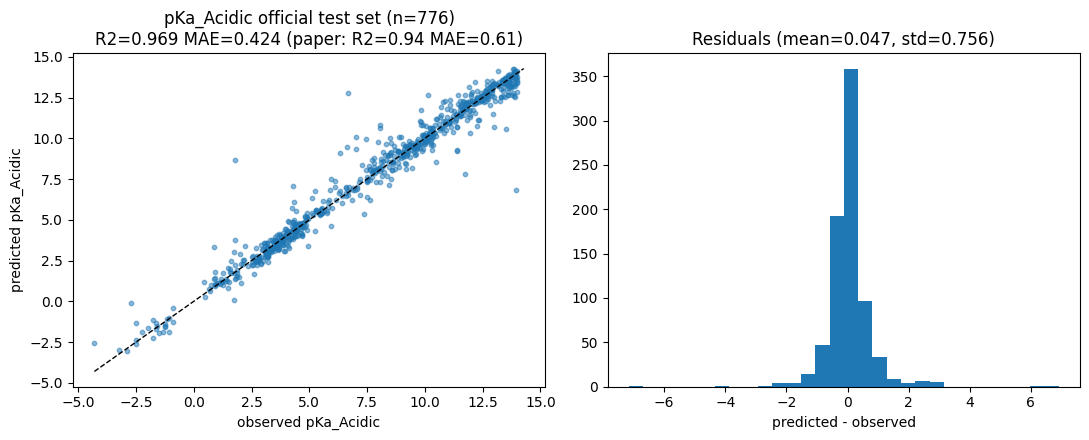

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(y_all[test_pos], pred, s=10, alpha=0.5)
lims = [min(y_all[test_pos].min(), pred.min()), max(y_all[test_pos].max(), pred.max())]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("observed " + TARGET); axes[0].set_ylabel("predicted " + TARGET)
axes[0].set_title(f"{TARGET} official test set (n={len(test_pos)})\nR2={m['R2']:.3f} MAE={m['MAE']:.3f} (paper: R2={paper['R2']} MAE={paper['MAE']})")

resid = pred - y_all[test_pos]
axes[1].hist(resid, bins=30)
axes[1].set_xlabel("predicted - observed"); axes[1].set_title(f"Residuals (mean={resid.mean():.3f}, std={resid.std():.3f})")
plt.tight_layout()
plt.savefig("../outputs/01_" + TARGET + "_official_test_plots.png", dpi=120)
plt.show()
